### Import Required Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load the Cleaned Dataset

In [3]:
df=pd.read_excel('../Project-1/cleaned_dataset.xlsx')

### Dataset Overview

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5


In [5]:
df.shape

(1200, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
 14  Year             1200 non-null   int64         
 15

In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,2023.767500,5.995000
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,2023.000000,1.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,2023.000000,3.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,2024.000000,6.000000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,2024.000000,9.000000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,2025.000000,12.000000
std,NaN,1.407557,197.177146,2.281983,819.856558,0.750942,3.344293


### Univariate Analysis of Numerical Columns

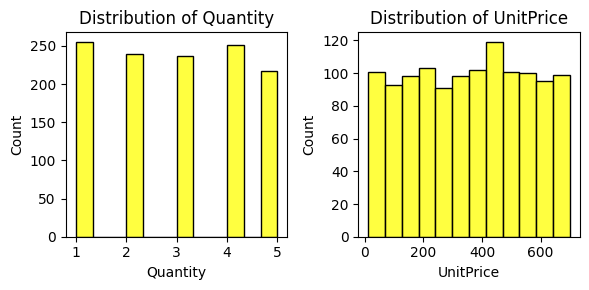

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.histplot(df['Quantity'],color='yellow',ax=axes[0])
axes[0].set_title('Distribution of Quantity')

sns.histplot(df['UnitPrice'],color='yellow',ax=axes[1])
axes[1].set_title('Distribution of UnitPrice')
plt.tight_layout()
plt.show()

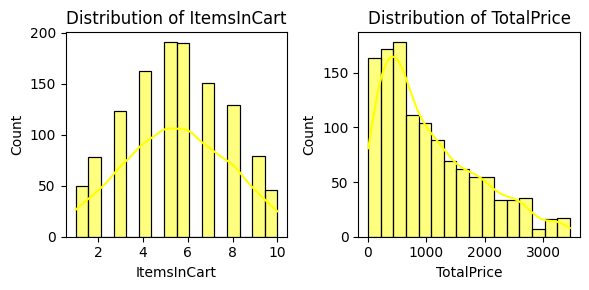

In [33]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.histplot(df['ItemsInCart'],color='yellow',ax=axes[0],kde=True)
axes[0].set_title('Distribution of ItemsInCart')

sns.histplot(df['TotalPrice'],color='yellow',ax=axes[1],kde=True)
axes[1].set_title('Distribution of TotalPrice')
plt.tight_layout()
plt.show()

### Observation

The distributions of Quantity, UnitPrice, and ItemsInCart are fairly balanced, with values spread across their respective ranges. The TotalPrice distribution was slightly right-skewed, indicating that most orders were of low to moderate value, while a smaller number of transactions contributed higher order values.

In [34]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].skew()

Quantity       0.027922
UnitPrice     -0.026512
ItemsInCart    0.000877
TotalPrice     0.891359
dtype: float64

In [35]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].kurtosis()

Quantity      -1.294596
UnitPrice     -1.191011
ItemsInCart   -0.708552
TotalPrice    -0.040415
dtype: float64

### Observation

The skewness and kurtosis values indicate that Quantity, UnitPrice, and ItemsInCart are fairly balanced and do not contain significant extreme values. TotalPrice shows a slight right skew, meaning that while most orders have moderate values, a few higher-value transactions are present. Overall, the numerical columns appear well distributed without any major irregularities.

### Check Outliers in Numerical Columns

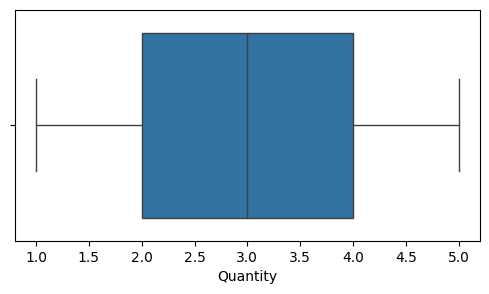

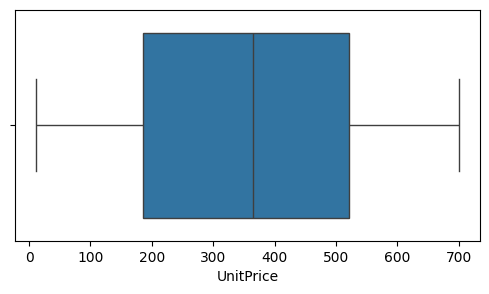

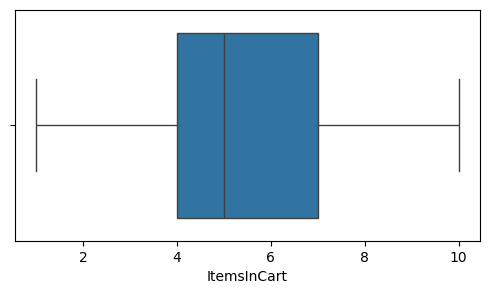

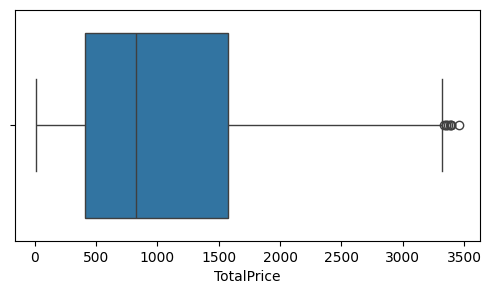

In [17]:
cols=['Quantity','UnitPrice','ItemsInCart','TotalPrice']
for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.show()

### Observation

Boxplots were used to identify potential outliers in numerical columns. No significant outliers were found in Quantity, UnitPrice, or ItemsInCart. A small number of outliers were observed in TotalPrice, representing high-value transactions. Since the TotalPrice values were previously validated and found to be accurate, these observations were retained in the dataset.

### Univariate Analysis of Categorical Columns

In [41]:
cols=['Product','PaymentMethod','OrderStatus','ReferralSource','CouponCode']
for col in cols:
    print(df[col].value_counts())
    print("--------")

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
--------
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
--------
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
--------
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64
--------
CouponCode
FREESHIP     313
NO COUPON    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64
--------


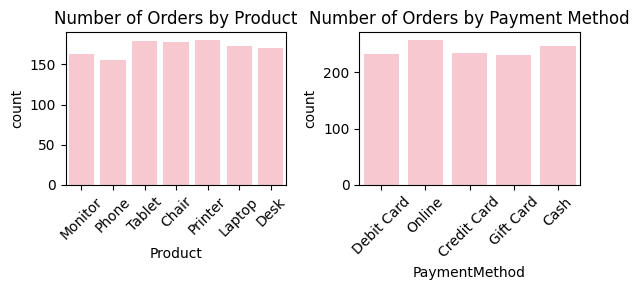

In [64]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.countplot(x=df['Product'],color='pink',ax=axes[0])
axes[0].set_title('Number of Orders by Product')
axes[0].tick_params(axis='x',rotation=45)

sns.countplot(x=df['PaymentMethod'],color='pink',ax=axes[1])
axes[1].set_title('Number of Orders by Payment Method')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

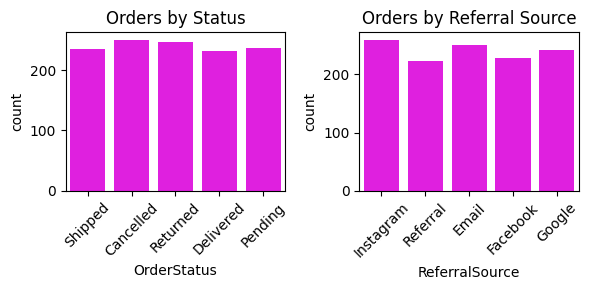

In [65]:
fig,axes=plt.subplots(1,2,figsize=(6,3))
sns.countplot(x=df['OrderStatus'],color='magenta',ax=axes[0])
axes[0].set_title('Orders by Status')
axes[0].tick_params(axis='x',rotation=45)

sns.countplot(x=df['ReferralSource'],color='magenta',ax=axes[1])
axes[1].set_title('Orders by Referral Source')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

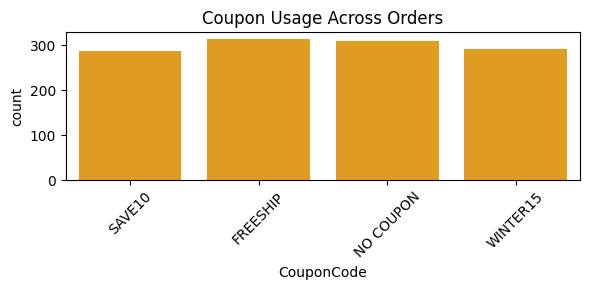

In [66]:
plt.figure(figsize=(6,3))
sns.countplot(x=df['CouponCode'],color='orange')
plt.title('Coupon Usage Across Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

From the count plots, it can be seen that the categories are distributed quite evenly. There are small differences in the counts, but no single product, payment method, order status, referral source, or coupon code stands out significantly from the others.

### Bivariate Analysis

### Product Performance Analysis

In [67]:
product_revenue=df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(product_revenue)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


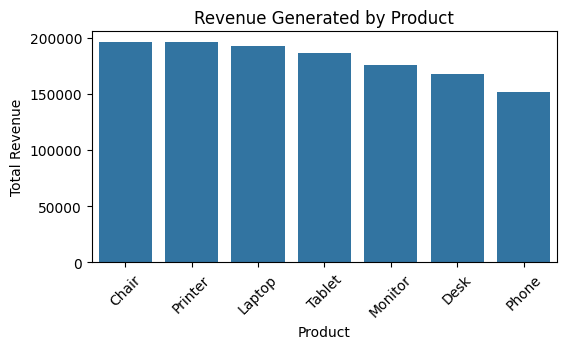

In [70]:
plt.figure(figsize=(6,3))
sns.barplot(x=product_revenue.index, y=product_revenue.values)
plt.title('Revenue Generated by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### Observation

The revenue generated by different products is fairly balanced. The highest revenue generated by Chairs and Printers, while Phones contributed the least.

### Product Demand Analysis

In [69]:
product_quantity=df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print(product_quantity)

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64


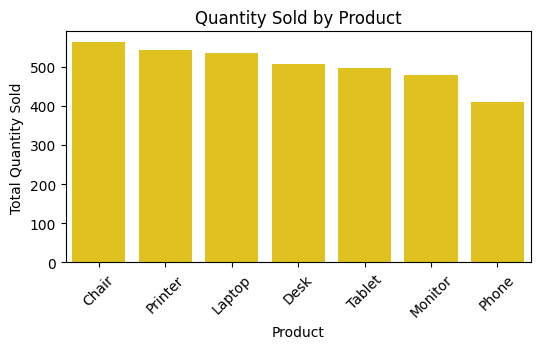

In [73]:
plt.figure(figsize=(6,3))
sns.barplot(x=product_quantity.index, y=product_quantity.values,color='gold')
plt.title('Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

### Observation

The quantity sold is fairly distributed across all products. Chairs, Printers, and Laptops have the highest sales volume, while Phones have the lowest. Overall, customer demand appears to be spread across multiple product categories rather than concentrated on a single product.

## Payment Method Analysis

In [74]:
payment_revenue=df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)
print(payment_revenue)

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64


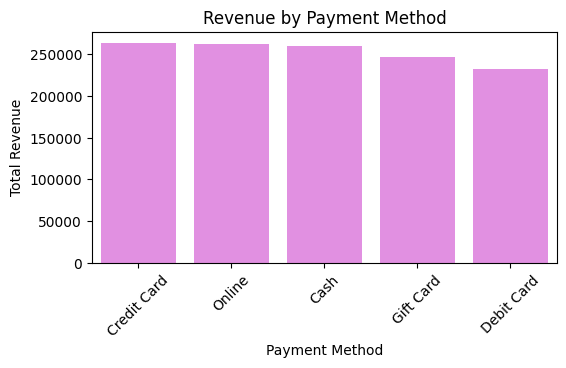

In [77]:
plt.figure(figsize=(6,3))
sns.barplot(x=payment_revenue.index, y=payment_revenue.values,color='violet')
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### Observation

The revenue generated across different payment methods is fairly balanced. Credit Card, Online, and Cash payments contribute slightly higher revenue, while Debit Card generates the lowest revenue.

### Referral Source Analysis

In [79]:
referral_revenue=df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
print(referral_revenue)

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64


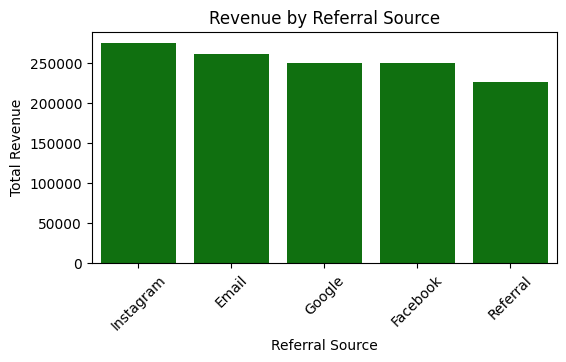

In [82]:
plt.figure(figsize=(6,3))
sns.barplot(x=referral_revenue.index, y=referral_revenue.values,color='green')
plt.title('Revenue by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### Observation

From the above chart, Instagram generated the highest revenue, followed by Email. Referral contributed the least revenue among all sources. Overall, the revenue difference between sources is not very large, but social media channels appear to perform slightly better.

### Order Status Analysis

In [83]:
status_revenue=df.groupby('OrderStatus')['TotalPrice'].sum().sort_values(ascending=False)
print(status_revenue)

OrderStatus
Cancelled    276396.21
Pending      256328.15
Shipped      246159.58
Returned     243277.70
Delivered    242600.32
Name: TotalPrice, dtype: float64


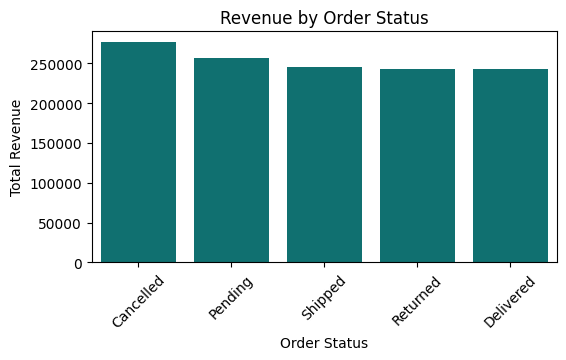

In [84]:
plt.figure(figsize=(6,3))
sns.barplot(x=status_revenue.index, y=status_revenue.values,color='teal')
plt.title('Revenue by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### Observation

From the chart, it is noticed that revenue is distributed across all order statuses. Cancelled orders show the highest total value, while Delivered orders show the lowest. It seems unusual  in real e-commerce data because cancelled orders would not generate high revenue.

### Customer Behavior Analysis

In [87]:
df['CustomerID'].nunique()

1189

In [89]:
customer_orders = df.groupby('CustomerID').size()
print(customer_orders.describe())

count    1189.000000
mean        1.009251
std         0.095779
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
dtype: float64


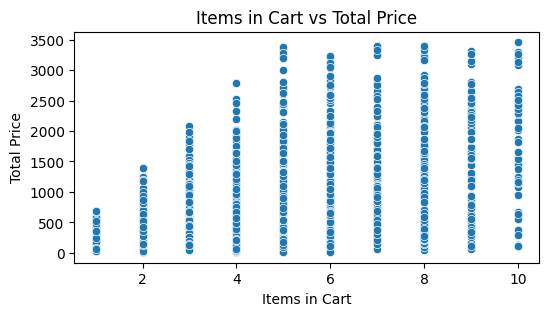

In [90]:
plt.figure(figsize=(6,3))
sns.scatterplot(x='ItemsInCart',y='TotalPrice',data=df)
plt.title('Items in Cart vs Total Price')
plt.xlabel('Items in Cart')
plt.ylabel('Total Price')
plt.show()

### Observation

From the plot, it is noticed that customers with more items in their cart often have higher order values. However, this trend is not perfectly consistent because different products have different prices. As a result, some orders with fewer items can still have a high total price.

### Time-Based Analysis

In [91]:
year_orders = df['Year'].value_counts().sort_index()
print(year_orders)

Year
2023    510
2024    459
2025    231
Name: count, dtype: int64


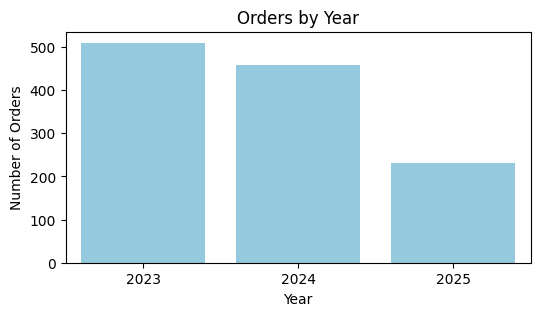

In [92]:
plt.figure(figsize=(6,3))
sns.barplot(x=year_orders.index,y=year_orders.values,color='skyblue')
plt.title('Orders by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.show()

In [93]:
month_orders = (df.groupby('Month').size().sort_index())
print(month_orders)

Month
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
dtype: int64


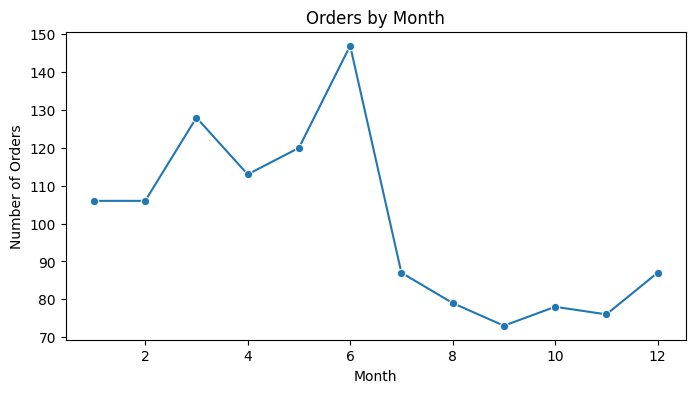

In [94]:
plt.figure(figsize=(8,4))
sns.lineplot(x=month_orders.index,y=month_orders.values,marker='o')
plt.title('Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

In [95]:
monthly_revenue = (df.groupby('Month')['TotalPrice'].sum().sort_index())
print(monthly_revenue)

Month
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64


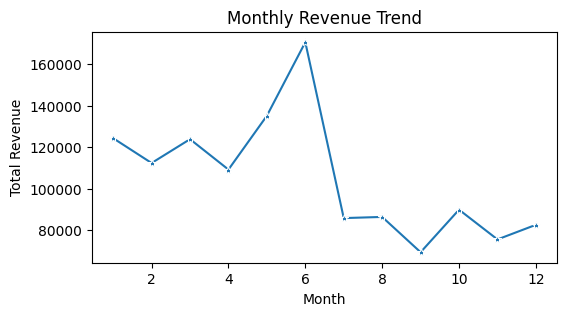

In [97]:
plt.figure(figsize=(6,3))
sns.lineplot(x=monthly_revenue.index,y=monthly_revenue.values,marker='*')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

### Observation

From above graphs it is noticed that the months with more orders also tend to generate more revenue. Month 6 had the highest activity, while the later months showed lower sales and fewer orders.

### Correlation Analysis

In [98]:

cor = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr()
print(cor)

             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


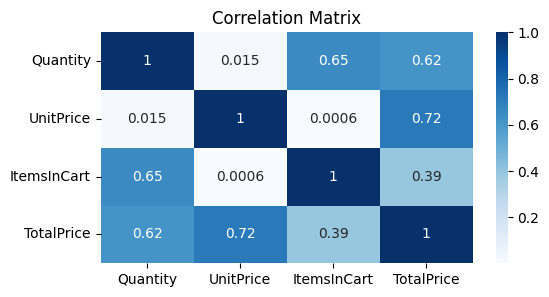

In [99]:
plt.figure(figsize=(6,3))
sns.heatmap( cor,annot=True,cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

### Observation

The strongest positive relationships are between UnitPrice and TotalPrice, and between Quantity and TotalPrice. This indicates that higher-priced products and larger purchase quantities contribute most to increasing the total order value.

### Key Findings

- Product sales and revenue were fairly balanced across all product categories.
- Chairs, Printers, and Laptops generated the highest sales and revenue.
- Instagram was the top referral source in terms of revenue.
- Most payment methods generated similar revenue.
- Month 6 recorded the highest number of orders and the highest revenue.
- Orders with more items in the cart generally had higher order values.
- Product price and quantity showed the strongest impact on total order value.